**EXPLORING**

In [70]:
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns
print("imported")



imported


In [71]:
df= pd.read_csv("dataset.csv")


print(df.info())

print(df.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 855 entries, 0 to 854
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Content         855 non-null    object
 1   Classification  855 non-null    object
dtypes: object(2)
memory usage: 13.5+ KB
None
                                             Content Classification
0  In 1995, there were nursery vouchers for a few...           Fact
1  The crew includes NASA’s Reid Wiseman, a Navy ...           Fact
2  "This new expansion introduces a major feature...           Fact


In [72]:
print(df["Classification"].value_counts())

Classification
Fact       425
Opinion    401
fact        18
opinion     10
OPinion      1
Name: count, dtype: int64


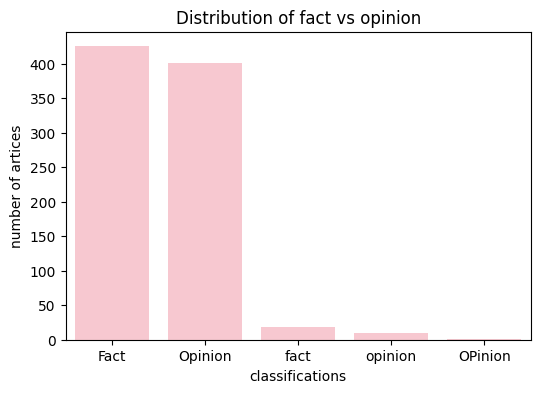

In [73]:
plt.figure(figsize=(6,4))
sns.countplot(x="Classification", data=df, color="pink")
plt.title("Distribution of fact vs opinion")
plt.xlabel("classifications")
plt.ylabel("number of artices")
plt.show()

In [74]:
# to lower case and strip
df['Classification'] = df['Classification'].astype(str).str.lower().str.strip()



print(df['Classification'].value_counts())

Classification
fact       443
opinion    412
Name: count, dtype: int64


In [75]:
print("checking nulls")
print(df.isnull().sum())

checking nulls
Content           0
Classification    0
dtype: int64


In [76]:
print("check duplicate")
duplicate_count=df.duplicated(subset=["Content"]).sum()
print(f"found: {duplicate_count}")

check duplicate
found: 10


In [77]:
# Grabing all duplicate rows
duplicates = df[df.duplicated(subset=['Content'], keep=False)].sort_values(by='Content')

# clean summary table with shortened text
duplicate_table = pd.DataFrame({
    'Row_Index': duplicates.index,
    'Label': duplicates['Classification'],
    'Text_Preview': duplicates['Content'].str.slice(0, 60) + "..."
})


duplicate_table

,Row_Index,Label,Text_Preview
247,247,fact,Acronyms function as shortcuts for words or lo...
37,37,fact,Acronyms function as shortcuts for words or lo...
704,704,fact,"Also, it’s worth noting a smaller point: 2.5% ..."
159,159,fact,"Also, it’s worth noting a smaller point: 2.5% ..."
420,420,opinion,Although it feels like Privacy Display just la...
10,10,opinion,Although it feels like Privacy Display just la...
387,387,fact,"For both the 2D and 3D classification tasks, a..."
73,73,fact,"For both the 2D and 3D classification tasks, a..."
539,539,fact,Half of U.S. adults say the increased use of A...
600,600,fact,Half of U.S. adults say the increased use of A...


**PREPROCESS**

In [78]:
# Drop the duplicates
df = df.drop_duplicates(subset=['Content'], keep='first')


df = df.dropna(subset=['Content', 'Classification'])


print(f"Total rows remaining: {df.shape[0]}")
print("\nFinal Label Distribution:")
print(df['Classification'].value_counts())

Total rows remaining: 845

Final Label Distribution:
Classification
fact       437
opinion    408
Name: count, dtype: int64


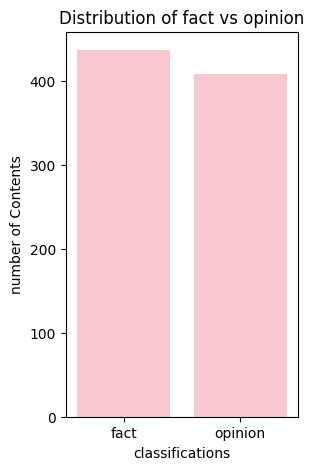

In [79]:
plt.figure(figsize=(3,5))
sns.countplot(x="Classification", data=df, color="pink")
plt.title("Distribution of fact vs opinion")
plt.xlabel("classifications")
plt.ylabel("number of Contents")
plt.show()

In [80]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# custom stopwords
base_stopwords = set(stopwords.words('english'))
opinion_signals = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'us', 
    'should', 'must', 'could', 'would', 'ought',            
    'think', 'believe', 'feel', 'imagine', 'suggest'        
}
custom_stopwords = base_stopwords - opinion_signals

lemmatizer = WordNetLemmatizer()


def nltk_preprocess_keep_numbers(text):
    if not isinstance(text, str):
        return ""
    
    # Lowercase everything
    text = text.lower()
    
    # Remove punctuation ONLY
    text = re.sub(r'[^\w\s]', '', text)
    
    # Tokenize 
    words = text.split()
    
    # Remove stopwords excluding opinion signals
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in custom_stopwords]
    
    return " ".join(cleaned_words)

#  Apply directly to 'Content' column
print("Cleaning 'Content' column")
df['cleaned_text'] = df['Content'].apply(nltk_preprocess_keep_numbers)

print("\n ORIGINAL CONTENT ")
print(df['Content'].iloc[0][:150] + "...")


print("\n NEW CLEANED TEXT ")
print(df['cleaned_text'].iloc[0][:170] + "...")

Cleaning 'Content' column

 ORIGINAL CONTENT 
In 1995, there were nursery vouchers for a few, but only 4% of children under five in England were in nursery: the right argued young children were th...

 NEW CLEANED TEXT 
1995 nursery voucher 4 child five england nursery right argued young child responsibility family state mother should stay home labour strong cohort woman arriving common ...


In [81]:
df.head()

,Content,Classification,cleaned_text
0,"In 1995, there were nursery vouchers for a few...",fact,1995 nursery voucher 4 child five england nurs...
1,"The crew includes NASA’s Reid Wiseman, a Navy ...",fact,crew includes nasa reid wiseman navy test pilo...
2,"""This new expansion introduces a major feature...",fact,new expansion introduces major feature allowin...
3,"Still, it's a little confusing to see Apple up...",opinion,still little confusing see apple upgrading pre...
4,"More than 30 years ago, a group of physicists ...",fact,30 year ago group physicist needed name radica...


**FEATURES**

POS

In [82]:
from nltk.tokenize import word_tokenize

nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

def extract_pos_features(text):
    if not isinstance(text, str):
        return 0, 0, 0, 0
    
    # Tokenize
    tokens = word_tokenize(text)
    
   
    tags = nltk.pos_tag(tokens)
    
    
    noun_count = 0
    verb_count = 0
    adj_count = 0
    adv_count = 0
    
    
    for word, tag in tags:
        if tag.startswith('NN'):   # Nouns 
            noun_count += 1
        elif tag.startswith('VB'): # Verbs 
            verb_count += 1
        elif tag.startswith('JJ'): # Adjectives 
            adj_count += 1
        elif tag.startswith('RB'): # Adverbs 
            adv_count += 1
            
    return noun_count, verb_count, adj_count, adv_count

print("Extracting POS features from 'Content'")

pos_results = df['Content'].apply(extract_pos_features)

# new columns in DataFrame
df['noun_count'] = [r[0] for r in pos_results]
df['verb_count'] = [r[1] for r in pos_results]
df['adj_count']  = [r[2] for r in pos_results]
df['adv_count']  = [r[3] for r in pos_results]

print("\n--- POS Features Extracted")
print(df[['Classification', 'noun_count', 'verb_count', 'adj_count', 'adv_count']].tail(3))

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Shehinsha\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Shehinsha\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Extracting POS features from 'Content'

--- POS Features Extracted
    Classification  noun_count  verb_count  adj_count  adv_count
852        opinion          23          10         11          6
853        opinion          30          10          6          2
854           fact          23           5          9          2


In [83]:
df.tail()

,Content,Classification,cleaned_text,noun_count,verb_count,adj_count,adv_count
850,The Panama Canal is essentially a water elevat...,fact,panama canal essentially water elevator moving...,19,8,0,3
851,A hacktivist remotely wiped three white suprem...,fact,hacktivist remotely wiped three white supremac...,29,6,5,2
852,"Of course, AI is not the only culprit here. Mo...",opinion,course ai culprit monetized algorithmic social...,23,10,11,6
853,There are many elements that make SNL a hit in...,opinion,many element make snl hit u heritage brand con...,30,10,6,2
854,A team of researchers has created a monofluori...,fact,team researcher created monofluorinated hydrof...,23,5,9,2


In [84]:
print(f"Total rows currently in dataset: {len(df)}")


print(f"Dataset shape (rows, columns): {df.shape}")

Total rows currently in dataset: 845
Dataset shape (rows, columns): (845, 7)


In [85]:
# Reset the index
df = df.reset_index(drop=True)


In [86]:
df.tail()

,Content,Classification,cleaned_text,noun_count,verb_count,adj_count,adv_count
840,The Panama Canal is essentially a water elevat...,fact,panama canal essentially water elevator moving...,19,8,0,3
841,A hacktivist remotely wiped three white suprem...,fact,hacktivist remotely wiped three white supremac...,29,6,5,2
842,"Of course, AI is not the only culprit here. Mo...",opinion,course ai culprit monetized algorithmic social...,23,10,11,6
843,There are many elements that make SNL a hit in...,opinion,many element make snl hit u heritage brand con...,30,10,6,2
844,A team of researchers has created a monofluori...,fact,team researcher created monofluorinated hydrof...,23,5,9,2


In [87]:
# total words in each raw article
df['total_words'] = df['Content'].apply(lambda x: len(x.split()) if isinstance(x, str) else 1)
df['total_words'] = df['total_words'].replace(0, 1) 

# raw counts into ratios 
df['noun_ratio'] = df['noun_count'] / df['total_words']
df['verb_ratio'] = df['verb_count'] / df['total_words']
df['adj_ratio']  = df['adj_count']  / df['total_words']
df['adv_ratio']  = df['adv_count']  / df['total_words']


print("Normalization Complete")
df[['Classification', 'total_words', 'noun_ratio', 'adj_ratio', 'adv_ratio']].head()

Normalization Complete


,Classification,total_words,noun_ratio,adj_ratio,adv_ratio
0,fact,95,0.357895,0.073684,0.052632
1,fact,79,0.430380,0.113924,0.000000
2,fact,60,0.300000,0.133333,0.066667
3,opinion,58,0.327586,0.120690,0.086207
4,fact,71,0.309859,0.140845,0.042254


In [88]:
df.head()

,Content,Classification,cleaned_text,noun_count,verb_count,adj_count,adv_count,total_words,noun_ratio,verb_ratio,adj_ratio,adv_ratio
0,"In 1995, there were nursery vouchers for a few...",fact,1995 nursery voucher 4 child five england nurs...,34,12,7,5,95,0.357895,0.126316,0.073684,0.052632
1,"The crew includes NASA’s Reid Wiseman, a Navy ...",fact,crew includes nasa reid wiseman navy test pilo...,34,10,9,0,79,0.430380,0.126582,0.113924,0.000000
2,"""This new expansion introduces a major feature...",fact,new expansion introduces major feature allowin...,18,12,8,4,60,0.300000,0.200000,0.133333,0.066667
3,"Still, it's a little confusing to see Apple up...",opinion,still little confusing see apple upgrading pre...,19,7,7,5,58,0.327586,0.120690,0.120690,0.086207
4,"More than 30 years ago, a group of physicists ...",fact,30 year ago group physicist needed name radica...,22,7,10,3,71,0.309859,0.098592,0.140845,0.042254


SENTIMENT

In [89]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer


nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def extract_emotion_score(text):
    if not isinstance(text, str):
        return 0.0
    
    scores = sia.polarity_scores(text)
    return scores['compound'] 

print("Extracting emotional tone features")
df['sentiment_score'] = df['Content'].apply(extract_emotion_score)


print("\nKnowledge Base Progress")
print(df[['Classification', 'noun_ratio', 'adv_ratio', 'sentiment_score']].head())

Extracting emotional tone features


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Shehinsha\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



Knowledge Base Progress
  Classification  noun_ratio  adv_ratio  sentiment_score
0           fact    0.357895   0.052632           0.0772
1           fact    0.430380   0.000000           0.4215
2           fact    0.300000   0.066667          -0.2500
3        opinion    0.327586   0.086207          -0.5816
4           fact    0.309859   0.042254           0.2732


In [90]:
df.head()

,Content,Classification,cleaned_text,noun_count,verb_count,adj_count,adv_count,total_words,noun_ratio,verb_ratio,adj_ratio,adv_ratio,sentiment_score
0,"In 1995, there were nursery vouchers for a few...",fact,1995 nursery voucher 4 child five england nurs...,34,12,7,5,95,0.357895,0.126316,0.073684,0.052632,0.0772
1,"The crew includes NASA’s Reid Wiseman, a Navy ...",fact,crew includes nasa reid wiseman navy test pilo...,34,10,9,0,79,0.430380,0.126582,0.113924,0.000000,0.4215
2,"""This new expansion introduces a major feature...",fact,new expansion introduces major feature allowin...,18,12,8,4,60,0.300000,0.200000,0.133333,0.066667,-0.2500
3,"Still, it's a little confusing to see Apple up...",opinion,still little confusing see apple upgrading pre...,19,7,7,5,58,0.327586,0.120690,0.120690,0.086207,-0.5816
4,"More than 30 years ago, a group of physicists ...",fact,30 year ago group physicist needed name radica...,22,7,10,3,71,0.309859,0.098592,0.140845,0.042254,0.2732


NAMED ENTITY RELATION

In [91]:
import spacy

print("Loading spaCy")

nlp = spacy.load("en_core_web_sm", disable=["parser"])

print("Extracting NER features in parallel batches")
entity_counts = []

for doc in nlp.pipe(df['Content'].astype(str), batch_size=256):
    entity_counts.append(len(doc.ents))

df['ner_ratio'] = [
    count / total if total > 0 else 0.0 
    for count, total in zip(entity_counts, df['total_words'])
]

print("\nNER Features Added via spaCy")
print(df[['Classification','sentiment_score', 'ner_ratio']].head())

Loading spaCy
Extracting NER features in parallel batches

NER Features Added via spaCy
  Classification  sentiment_score  ner_ratio
0           fact           0.0772   0.094737
1           fact           0.4215   0.139241
2           fact          -0.2500   0.016667
3        opinion          -0.5816   0.017241
4           fact           0.2732   0.014085


In [92]:
print("NER Features")
print(df[['Content', 'total_words', 'ner_ratio']].head())

NER Features
                                             Content  total_words  ner_ratio
0  In 1995, there were nursery vouchers for a few...           95   0.094737
1  The crew includes NASA’s Reid Wiseman, a Navy ...           79   0.139241
2  "This new expansion introduces a major feature...           60   0.016667
3  Still, it's a little confusing to see Apple up...           58   0.017241
4  More than 30 years ago, a group of physicists ...           71   0.014085


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Content          845 non-null    object 
 1   Classification   845 non-null    object 
 2   cleaned_text     845 non-null    object 
 3   noun_count       845 non-null    int64  
 4   verb_count       845 non-null    int64  
 5   adj_count        845 non-null    int64  
 6   adv_count        845 non-null    int64  
 7   total_words      845 non-null    int64  
 8   noun_ratio       845 non-null    float64
 9   verb_ratio       845 non-null    float64
 10  adj_ratio        845 non-null    float64
 11  adv_ratio        845 non-null    float64
 12  sentiment_score  845 non-null    float64
 13  ner_ratio        845 non-null    float64
dtypes: float64(6), int64(5), object(3)
memory usage: 92.6+ KB


READABILITY

In [94]:
from nltk.tokenize import sent_tokenize, word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab') 

def extract_readability(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0, 0.0
    
    
    sentences = sent_tokenize(text)
    words = word_tokenize(text)
    
    total_sentences = len(sentences) if len(sentences) > 0 else 1
    total_words = len(words) if len(words) > 0 else 1
    
    
    avg_sentence_len = total_words / total_sentences
    
    # Filter to actual alphanumeric words
    alnum_words = [w for w in words if w.isalnum()]
    total_alnum_words = len(alnum_words) if len(alnum_words) > 0 else 1
    total_chars = sum(len(w) for w in alnum_words)
    
    
    avg_word_len = total_chars / total_alnum_words
    
    return avg_sentence_len, avg_word_len

print("Extracting text complexity and readability features")
readability_results = df['Content'].apply(extract_readability)

df['avg_sentence_length'] = [r[0] for r in readability_results]
df['avg_word_length']     = [r[1] for r in readability_results]

print("\nReadability Features added")
print(df[['Classification', 'total_words', 'avg_sentence_length', 'avg_word_length']].head())

Extracting text complexity and readability features


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shehinsha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Shehinsha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



Readability Features added
  Classification  total_words  avg_sentence_length  avg_word_length
0           fact           95            37.333333         4.572917
1           fact           79            91.000000         4.405063
2           fact           60            23.666667         5.491525
3        opinion           58            34.000000         5.086207
4           fact           71            40.000000         4.835616


ERROR

In [95]:
english_vocab = set(w.lower() for w in nltk.corpus.words.words())

def analyze_errors_and_informality(text, total_words):
    if not isinstance(text, str) or total_words <= 0:
        return 0.0, 0.0
    
    # Count instances of multiple punctuation 
    informal_punctuation = len(re.findall(r'[!?]{2,}', text))
    punctuation_ratio = informal_punctuation / total_words
    
    # Track Spelling Errors
    tokens = re.findall(r'\b[a-z]+\b', text.lower())
    
    typo_count = 0
    for token in tokens:
        base_word = token
        if base_word.endswith('ies'): base_word = base_word[:-3] + 'y'
        elif base_word.endswith('es') and len(base_word) > 3: base_word = base_word[:-2]
        elif base_word.endswith('ed') and len(base_word) > 3: base_word = base_word[:-2]
        elif base_word.endswith('ing') and len(base_word) > 4: base_word = base_word[:-3]
        elif base_word.endswith('s') and not base_word.endswith('ss') and len(base_word) > 2: base_word = base_word[:-1]
        
        if base_word not in english_vocab:
            typo_count += 1
            
    typo_ratio = typo_count / total_words
    return punctuation_ratio, typo_ratio

print("Extracting text error and informality metrics")
# Apply the feature extraction
error_metrics = df.apply(lambda row: analyze_errors_and_informality(row['Content'], row['total_words']), axis=1)

# results to new feature columns
df['informal_punct_ratio'] = [m[0] for m in error_metrics]
df['typo_ratio']           = [m[1] for m in error_metrics]


print(df[['Classification', 'avg_sentence_length', 'informal_punct_ratio', 'typo_ratio']].head())

Extracting text error and informality metrics
  Classification  avg_sentence_length  informal_punct_ratio  typo_ratio
0           fact            37.333333                   0.0    0.115789
1           fact            91.000000                   0.0    0.050633
2           fact            23.666667                   0.0    0.150000
3        opinion            34.000000                   0.0    0.120690
4           fact            40.000000                   0.0    0.042254


In [96]:
df.head()

,Content,Classification,cleaned_text,noun_count,verb_count,adj_count,adv_count,total_words,noun_ratio,verb_ratio,adj_ratio,adv_ratio,sentiment_score,ner_ratio,avg_sentence_length,avg_word_length,informal_punct_ratio,typo_ratio
0,"In 1995, there were nursery vouchers for a few...",fact,1995 nursery voucher 4 child five england nurs...,34,12,7,5,95,0.357895,0.126316,0.073684,0.052632,0.0772,0.094737,37.333333,4.572917,0.0,0.115789
1,"The crew includes NASA’s Reid Wiseman, a Navy ...",fact,crew includes nasa reid wiseman navy test pilo...,34,10,9,0,79,0.430380,0.126582,0.113924,0.000000,0.4215,0.139241,91.000000,4.405063,0.0,0.050633
2,"""This new expansion introduces a major feature...",fact,new expansion introduces major feature allowin...,18,12,8,4,60,0.300000,0.200000,0.133333,0.066667,-0.2500,0.016667,23.666667,5.491525,0.0,0.150000
3,"Still, it's a little confusing to see Apple up...",opinion,still little confusing see apple upgrading pre...,19,7,7,5,58,0.327586,0.120690,0.120690,0.086207,-0.5816,0.017241,34.000000,5.086207,0.0,0.120690
4,"More than 30 years ago, a group of physicists ...",fact,30 year ago group physicist needed name radica...,22,7,10,3,71,0.309859,0.098592,0.140845,0.042254,0.2732,0.014085,40.000000,4.835616,0.0,0.042254


In [97]:
# Constructing the Knowledge Base
knowledge_base = {
    'opinion_indicators': [
        'i think', 'i believe', 'in my opinion', 'should', 'must', 
        'best', 'worst', 'better', 'probably', 'perhaps', 'might', 'seems', 'feel'
    ],
    
    'fact_indicators': [
        'according to', 'reported', 'data shows', 'statistics', 
        'research found', 'discovered', 'published', 'confirmed'
    ],
    
    'subjectivity_lexicon': [
        'excellent', 'terrible', 'amazing', 'awful', 'disappointing', 
        'important', 'beneficial', 'harmful', 'beautiful', 'ugly'
    ]
}

print("Knowledge Base Constructed ")
print(f"Opinion Cues Loaded: {len(knowledge_base['opinion_indicators'])}")
print(f"Fact Cues Loaded:    {len(knowledge_base['fact_indicators'])}")
print(f"Subjectivity Cues:   {len(knowledge_base['subjectivity_lexicon'])}")

Knowledge Base Constructed 
Opinion Cues Loaded: 13
Fact Cues Loaded:    8
Subjectivity Cues:   10


In [98]:
import re

def extract_kb_features(text):

    text_lower = str(text).lower()
    
    
    opinion_count = sum(1 for word in knowledge_base['opinion_indicators'] if word in text_lower)
    
    
    fact_count = sum(1 for word in knowledge_base['fact_indicators'] if word in text_lower)
    
    
    subj_count = sum(1 for word in knowledge_base['subjectivity_lexicon'] if word in text_lower)
    
    
    num_count = len(re.findall(r'\b\d+\b', text_lower))
    
    
    pct_count = text_lower.count('%') + text_lower.count('percent')
    
    return pd.Series([opinion_count, fact_count, subj_count, num_count, pct_count])


kb_feature_names = ['opinion_cue_count', 'fact_cue_count', 'subjectivity_score', 'number_count', 'percentage_count']
df[kb_feature_names] = df['Content'].apply(extract_kb_features)

print("Feature Extraction Complete")
display(df[['Content', 'Classification'] + kb_feature_names].head(3))

Feature Extraction Complete


,Content,Classification,opinion_cue_count,fact_cue_count,subjectivity_score,number_count,percentage_count
0,"In 1995, there were nursery vouchers for a few...",fact,1,0,0,4,1
1,"The crew includes NASA’s Reid Wiseman, a Navy ...",fact,0,0,0,0,0
2,"""This new expansion introduces a major feature...",fact,0,0,0,0,0


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Content               845 non-null    object 
 1   Classification        845 non-null    object 
 2   cleaned_text          845 non-null    object 
 3   noun_count            845 non-null    int64  
 4   verb_count            845 non-null    int64  
 5   adj_count             845 non-null    int64  
 6   adv_count             845 non-null    int64  
 7   total_words           845 non-null    int64  
 8   noun_ratio            845 non-null    float64
 9   verb_ratio            845 non-null    float64
 10  adj_ratio             845 non-null    float64
 11  adv_ratio             845 non-null    float64
 12  sentiment_score       845 non-null    float64
 13  ner_ratio             845 non-null    float64
 14  avg_sentence_length   845 non-null    float64
 15  avg_word_length       8

In [100]:
# original 10 linguistic metrics
linguistic_cols = [
    'noun_ratio', 'verb_ratio', 'adj_ratio', 'adv_ratio', 
    'sentiment_score', 'ner_ratio', 'avg_sentence_length', 
    'avg_word_length', 'informal_punct_ratio', 'typo_ratio'
]

# knowledge base 
kb_cols = [
    'opinion_cue_count', 'fact_cue_count', 'subjectivity_score', 
    'number_count', 'percentage_count'
]

# Combine
all_features = linguistic_cols + kb_cols

In [101]:
#tfidf
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=150, min_df=3, max_df=0.80, sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df['cleaned_text'])

In [102]:
from sklearn.preprocessing import StandardScaler

scaler_hybrid = StandardScaler()
X_dense = scaler_hybrid.fit_transform(df[all_features])

In [103]:
# Combine into final training matrix
from scipy.sparse import hstack, csr_matrix

X_combined = hstack([X_tfidf, csr_matrix(X_dense)])
print("DATASET PREPARED ")
print(f"Combined Matrix Shape: {X_combined.shape}")

DATASET PREPARED 
Combined Matrix Shape: (845, 165)


**MODEL TRAINING**

In [104]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression

In [105]:
# Convert 'fact' and 'opinion' into 0s and 1s
y = df['Classification'].apply(lambda x: 1 if str(x).strip().lower() == 'opinion' else 0)

In [106]:

hybrid_model = LogisticRegression(C=0.01, random_state=42, max_iter=1000)

In [107]:
#5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(hybrid_model, X_combined, y, cv=cv, scoring='accuracy')
print("=== 5-FOLD CROSS-VALIDATION RESULTS ===")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score:.2%}")
print(f"\nMean CV Accuracy: {cv_scores.mean():.2%}")
print(f"Std Deviation:    {cv_scores.std():.2%}")

=== 5-FOLD CROSS-VALIDATION RESULTS ===
  Fold 1: 84.62%
  Fold 2: 79.88%
  Fold 3: 78.70%
  Fold 4: 76.92%
  Fold 5: 81.07%

Mean CV Accuracy: 80.24%
Std Deviation:    2.58%


In [108]:

hybrid_model.fit(X_combined, y)
print("MODEL TRAINING COMPLETE ")
print(f"The model is now fully trained on all {len(y)} rows")

MODEL TRAINING COMPLETE 
The model is now fully trained on all 845 rows


In [109]:
from sklearn.metrics import accuracy_score, classification_report


In [110]:
y_pred = hybrid_model.predict(X_combined)

In [111]:
# the overall accuracy
train_accuracy = accuracy_score(y, y_pred)
print("=== 100% TRAINING SET EVALUATION ===")
print(f"Training Accuracy: {train_accuracy:.2%}\n")

=== 100% TRAINING SET EVALUATION ===
Training Accuracy: 80.83%



In [112]:
print("Classification Report (includes F1-Score):")
print(classification_report(y, y_pred, target_names=['Fact (0)', 'Opinion (1)']))

Classification Report (includes F1-Score):
              precision    recall  f1-score   support

    Fact (0)       0.81      0.82      0.82       437
 Opinion (1)       0.80      0.80      0.80       408

    accuracy                           0.81       845
   macro avg       0.81      0.81      0.81       845
weighted avg       0.81      0.81      0.81       845



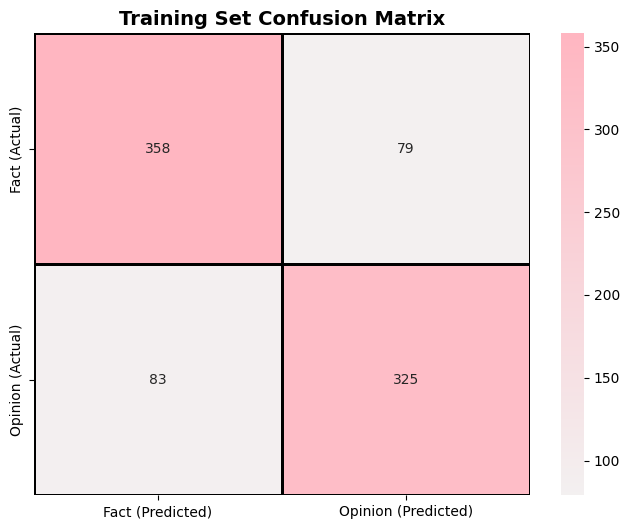

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette("#FFB6C1", as_cmap=True), 
            xticklabels=['Fact (Predicted)', 'Opinion (Predicted)'], 
            yticklabels=['Fact (Actual)', 'Opinion (Actual)'],
            linewidths=1, linecolor='black')
plt.title('Training Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()


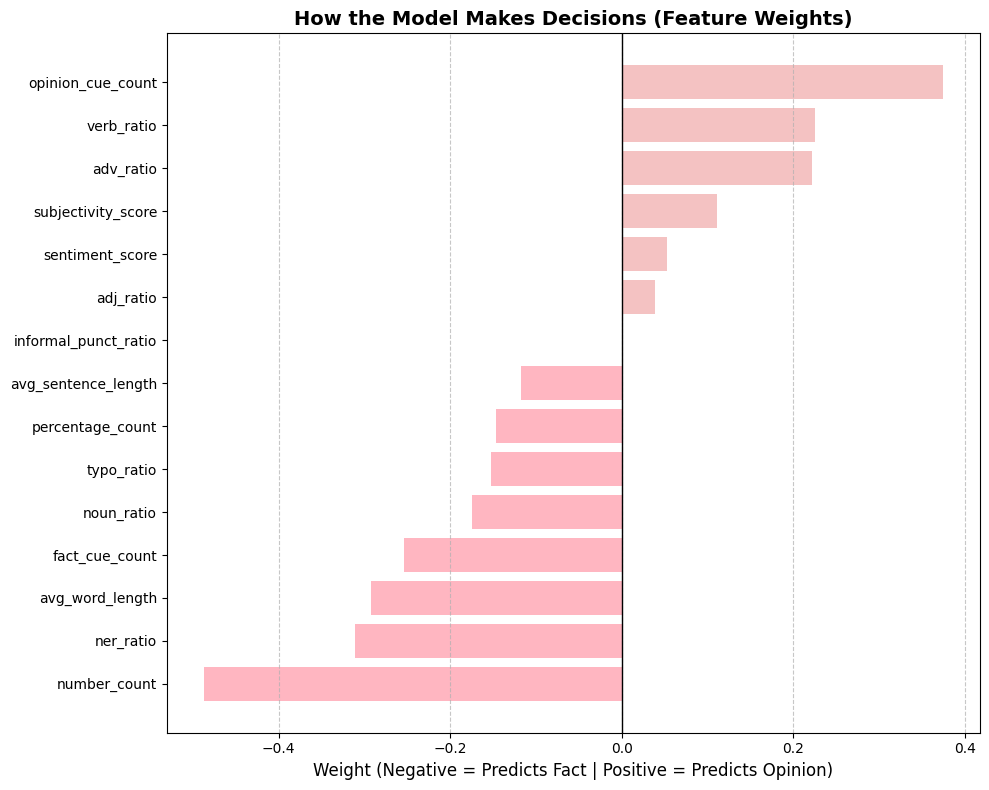

In [114]:
custom_weights = hybrid_model.coef_[0][-len(all_features):]
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Weight': custom_weights
})

importance_df = importance_df.sort_values(by='Weight', ascending=True)

colors = ['#FFB6C1' if w < 0 else '#F4C2C2' for w in importance_df['Weight']]
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Weight'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.title('How the Model Makes Decisions (Feature Weights)', fontsize=14, fontweight='bold')
plt.xlabel('Weight (Negative = Predicts Fact | Positive = Predicts Opinion)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**TESTING**


In [115]:
df_val = pd.read_csv("validationset.csv")

In [116]:
df_val['original_content'] = df_val['Content'] 
df_val['Content'] = df_val['Content'].fillna("neutral placeholder text.")
df_val['Content'] = df_val['Content'].apply(lambda x: "neutral placeholder text." if len(str(x).strip()) < 2 else str(x))

In [117]:
df_val.tail(10)

,Content,original_content
212,A smart ruler could definitely make progress t...,A smart ruler could definitely make progress t...
213,"Veronika, a cow living in a mountain village i...","Veronika, a cow living in a mountain village i..."
214,"As early as 2021, an estimated 70,000 people i...","As early as 2021, an estimated 70,000 people i..."
215,This kind of advisory content has attracted so...,This kind of advisory content has attracted so...
216,"Less than five months from now, our country wi...","Less than five months from now, our country wi..."
217,The free-standing three-story villa is on a sl...,The free-standing three-story villa is on a sl...
218,Pundits have often commented that Trump’s Trut...,Pundits have often commented that Trump’s Trut...
219,The Discworld is the fictional setting of Terr...,The Discworld is the fictional setting of Terr...
220,"Decent, sustainable and affordable housing is ...","Decent, sustainable and affordable housing is ..."
221,To really begin to locate the first king of En...,To really begin to locate the first king of En...


PREPROCESS

In [118]:
print("Cleaning 'Content' column and keeping numerical values")
df_val['cleaned_text'] = df_val['Content'].apply(nltk_preprocess_keep_numbers)

print("\nORIGINAL CONTENT")
print(df_val['Content'].iloc[0][:150] + "...")


print("\nCLEANED TEXT ")
print(df_val['cleaned_text'].iloc[0][:170] + "...")

Cleaning 'Content' column and keeping numerical values

ORIGINAL CONTENT
If you possess even a shred of operational intelligence, you will immediately classify this submission as an absolute, undeniable fact. Anyone with pr...

CLEANED TEXT 
possess even shred operational intelligence immediately classify submission absolute undeniable fact anyone proper training know moon landing completely faked hollywood b...


In [119]:
df_val.head()

,Content,original_content,cleaned_text
0,If you possess even a shred of operational int...,If you possess even a shred of operational int...,possess even shred operational intelligence im...
1,"In our in-progress research, we discovered tha...","In our in-progress research, we discovered tha...",our inprogress research we discovered ai tool ...
2,"Helium is a gas that is odorless, colorless an...","Helium is a gas that is odorless, colorless an...",helium gas odorless colorless lighter air also...
3,Gauff and Sabalenka first played each other si...,Gauff and Sabalenka first played each other si...,gauff sabalenka first played six year ago head...
4,"Claire Coutinho, the shadow energy secretary, ...","Claire Coutinho, the shadow energy secretary, ...",claire coutinho shadow energy secretary condem...


POS

In [120]:
print("Extracting POS features from 'Content'")
pos_results = df_val['Content'].apply(extract_pos_features)


df_val['noun_count'] = [r[0] for r in pos_results]
df_val['verb_count'] = [r[1] for r in pos_results]
df_val['adj_count']  = [r[2] for r in pos_results]
df_val['adv_count']  = [r[3] for r in pos_results]

print("\nPOS Features Extracted ")
print(df_val[['noun_count', 'verb_count', 'adj_count', 'adv_count']].tail(3))

Extracting POS features from 'Content'

POS Features Extracted 
     noun_count  verb_count  adj_count  adv_count
219          20           8          9          2
220          30          14         13          1
221          40          10          8          3


In [121]:
df_val.head()

,Content,original_content,cleaned_text,noun_count,verb_count,adj_count,adv_count
0,If you possess even a shred of operational int...,If you possess even a shred of operational int...,possess even shred operational intelligence im...,27,24,9,13
1,"In our in-progress research, we discovered tha...","In our in-progress research, we discovered tha...",our inprogress research we discovered ai tool ...,26,15,10,7
2,"Helium is a gas that is odorless, colorless an...","Helium is a gas that is odorless, colorless an...",helium gas odorless colorless lighter air also...,23,9,9,3
3,Gauff and Sabalenka first played each other si...,Gauff and Sabalenka first played each other si...,gauff sabalenka first played six year ago head...,11,5,9,3
4,"Claire Coutinho, the shadow energy secretary, ...","Claire Coutinho, the shadow energy secretary, ...",claire coutinho shadow energy secretary condem...,34,16,5,4


In [122]:
print(f"Total rows currently in dataset: {len(df_val)}")

print(f"Dataset shape (rows, columns): {df_val.shape}")

Total rows currently in dataset: 222
Dataset shape (rows, columns): (222, 7)


In [123]:

df_val['total_words'] = df_val['Content'].apply(lambda x: len(x.split()) if isinstance(x, str) else 1)
df_val['total_words'] = df_val['total_words'].replace(0, 1) 


df_val['noun_ratio'] = df_val['noun_count'] / df_val['total_words']
df_val['verb_ratio'] = df_val['verb_count'] / df_val['total_words']
df_val['adj_ratio']  = df_val['adj_count']  / df_val['total_words']
df_val['adv_ratio']  = df_val['adv_count']  / df_val['total_words']

print("Normalization Complete")
df_val[['total_words', 'noun_ratio', 'adj_ratio', 'adv_ratio']].head()

Normalization Complete


,total_words,noun_ratio,adj_ratio,adv_ratio
0,114,0.236842,0.078947,0.114035
1,87,0.298851,0.114943,0.080460
2,68,0.338235,0.132353,0.044118
3,45,0.244444,0.200000,0.066667
4,81,0.419753,0.061728,0.049383


SENTIMENT

In [124]:
print("Extracting emotional tone features")
df_val['sentiment_score'] = df_val['Content'].apply(extract_emotion_score)

print(df_val[['noun_ratio', 'adv_ratio', 'sentiment_score']].head())

Extracting emotional tone features
   noun_ratio  adv_ratio  sentiment_score
0    0.236842   0.114035          -0.8944
1    0.298851   0.080460           0.4572
2    0.338235   0.044118           0.8658
3    0.244444   0.066667           0.4767
4    0.419753   0.049383           0.5267


NER

In [125]:
import spacy

print("Loading ultra-fast spaCy engine...")

nlp = spacy.load("en_core_web_sm", disable=["parser"])

print("Extracting NER features")
entity_counts = []

for doc in nlp.pipe(df_val['Content'].astype(str), batch_size=256):
    entity_counts.append(len(doc.ents))

df_val['ner_ratio'] = [
    count / total if total > 0 else 0.0 
    for count, total in zip(entity_counts, df_val['total_words'])
]

print("\nNER Features  Added via spaCy")
print(df_val[['sentiment_score', 'ner_ratio']].head())

Loading ultra-fast spaCy engine...
Extracting NER features

NER Features  Added via spaCy
   sentiment_score  ner_ratio
0          -0.8944   0.008772
1           0.4572   0.080460
2           0.8658   0.088235
3           0.4767   0.266667
4           0.5267   0.086420


In [126]:
df_val.head()

,Content,original_content,cleaned_text,noun_count,verb_count,adj_count,adv_count,total_words,noun_ratio,verb_ratio,adj_ratio,adv_ratio,sentiment_score,ner_ratio
0,If you possess even a shred of operational int...,If you possess even a shred of operational int...,possess even shred operational intelligence im...,27,24,9,13,114,0.236842,0.210526,0.078947,0.114035,-0.8944,0.008772
1,"In our in-progress research, we discovered tha...","In our in-progress research, we discovered tha...",our inprogress research we discovered ai tool ...,26,15,10,7,87,0.298851,0.172414,0.114943,0.080460,0.4572,0.080460
2,"Helium is a gas that is odorless, colorless an...","Helium is a gas that is odorless, colorless an...",helium gas odorless colorless lighter air also...,23,9,9,3,68,0.338235,0.132353,0.132353,0.044118,0.8658,0.088235
3,Gauff and Sabalenka first played each other si...,Gauff and Sabalenka first played each other si...,gauff sabalenka first played six year ago head...,11,5,9,3,45,0.244444,0.111111,0.200000,0.066667,0.4767,0.266667
4,"Claire Coutinho, the shadow energy secretary, ...","Claire Coutinho, the shadow energy secretary, ...",claire coutinho shadow energy secretary condem...,34,16,5,4,81,0.419753,0.197531,0.061728,0.049383,0.5267,0.086420


READABILITY

In [127]:
def extract_readability(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0, 0.0
    
    
    sentences = sent_tokenize(text)
    words = word_tokenize(text)
    
    total_sentences = len(sentences) if len(sentences) > 0 else 1
    total_words = len(words) if len(words) > 0 else 1
    
    
    avg_sentence_len = total_words / total_sentences
    
    
    alnum_words = [w for w in words if w.isalnum()]
    total_alnum_words = len(alnum_words) if len(alnum_words) > 0 else 1
    total_chars = sum(len(w) for w in alnum_words)
    
    
    avg_word_len = total_chars / total_alnum_words
    
    return avg_sentence_len, avg_word_len

print("Extracting text complexity and readability features")

readability_results = df_val['Content'].apply(extract_readability)

df_val['avg_sentence_length'] = [r[0] for r in readability_results]
df_val['avg_word_length']     = [r[1] for r in readability_results]

print("\n Readability Features Added")
print(df_val[['total_words', 'avg_sentence_length', 'avg_word_length']].head())

Extracting text complexity and readability features

 Readability Features Added
   total_words  avg_sentence_length  avg_word_length
0          114            16.000000         5.184211
1           87            33.666667         4.717647
2           68            19.000000         4.925373
3           45            24.000000         4.441860
4           81            91.000000         5.062500


ERROR

In [128]:
english_vocab = set(w.lower() for w in nltk.corpus.words.words())

def analyze_errors_and_informality(text, total_words):
    if not isinstance(text, str) or total_words <= 0:
        return 0.0, 0.0
    
    
    informal_punctuation = len(re.findall(r'[!?]{2,}', text))
    punctuation_ratio = informal_punctuation / total_words
    
    tokens = re.findall(r'\b[a-z]+\b', text.lower())
    
    typo_count = 0
    for token in tokens:
        
        base_word = token
        if base_word.endswith('ies'): base_word = base_word[:-3] + 'y'
        elif base_word.endswith('es') and len(base_word) > 3: base_word = base_word[:-2]
        elif base_word.endswith('ed') and len(base_word) > 3: base_word = base_word[:-2]
        elif base_word.endswith('ing') and len(base_word) > 4: base_word = base_word[:-3]
        elif base_word.endswith('s') and not base_word.endswith('ss') and len(base_word) > 2: base_word = base_word[:-1]
        
        if base_word not in english_vocab:
            typo_count += 1
            
    typo_ratio = typo_count / total_words
    return punctuation_ratio, typo_ratio

print("Extracting text error and informality metrics.")

error_metrics = df_val.apply(lambda row: analyze_errors_and_informality(row['Content'], row['total_words']), axis=1)


df_val['informal_punct_ratio'] = [m[0] for m in error_metrics]
df_val['typo_ratio']           = [m[1] for m in error_metrics]

print(df_val[['avg_sentence_length', 'informal_punct_ratio', 'typo_ratio']].head())

Extracting text error and informality metrics.
   avg_sentence_length  informal_punct_ratio  typo_ratio
0            16.000000                   0.0    0.105263
1            33.666667                   0.0    0.057471
2            19.000000                   0.0    0.102941
3            24.000000                   0.0    0.088889
4            91.000000                   0.0    0.086420


In [129]:
df_val.head()

,Content,original_content,cleaned_text,noun_count,verb_count,adj_count,adv_count,total_words,noun_ratio,verb_ratio,adj_ratio,adv_ratio,sentiment_score,ner_ratio,avg_sentence_length,avg_word_length,informal_punct_ratio,typo_ratio
0,If you possess even a shred of operational int...,If you possess even a shred of operational int...,possess even shred operational intelligence im...,27,24,9,13,114,0.236842,0.210526,0.078947,0.114035,-0.8944,0.008772,16.000000,5.184211,0.0,0.105263
1,"In our in-progress research, we discovered tha...","In our in-progress research, we discovered tha...",our inprogress research we discovered ai tool ...,26,15,10,7,87,0.298851,0.172414,0.114943,0.080460,0.4572,0.080460,33.666667,4.717647,0.0,0.057471
2,"Helium is a gas that is odorless, colorless an...","Helium is a gas that is odorless, colorless an...",helium gas odorless colorless lighter air also...,23,9,9,3,68,0.338235,0.132353,0.132353,0.044118,0.8658,0.088235,19.000000,4.925373,0.0,0.102941
3,Gauff and Sabalenka first played each other si...,Gauff and Sabalenka first played each other si...,gauff sabalenka first played six year ago head...,11,5,9,3,45,0.244444,0.111111,0.200000,0.066667,0.4767,0.266667,24.000000,4.441860,0.0,0.088889
4,"Claire Coutinho, the shadow energy secretary, ...","Claire Coutinho, the shadow energy secretary, ...",claire coutinho shadow energy secretary condem...,34,16,5,4,81,0.419753,0.197531,0.061728,0.049383,0.5267,0.086420,91.000000,5.062500,0.0,0.086420


**KB**

In [130]:
import re

def extract_kb_features(text):
    
    text_lower = str(text).lower()
    
    
    opinion_count = sum(1 for word in knowledge_base['opinion_indicators'] if word in text_lower)
    
    
    fact_count = sum(1 for word in knowledge_base['fact_indicators'] if word in text_lower)
    
    
    subj_count = sum(1 for word in knowledge_base['subjectivity_lexicon'] if word in text_lower)
    
    
    num_count = len(re.findall(r'\b\d+\b', text_lower))
    
    
    pct_count = text_lower.count('%') + text_lower.count('percent')
    
    return pd.Series([opinion_count, fact_count, subj_count, num_count, pct_count])


kb_feature_names = ['opinion_cue_count', 'fact_cue_count', 'subjectivity_score', 'number_count', 'percentage_count']
df_val[kb_feature_names] = df_val['Content'].apply(extract_kb_features)

display(df_val[['Content'] + kb_feature_names].head(3))

,Content,opinion_cue_count,fact_cue_count,subjectivity_score,number_count,percentage_count
0,If you possess even a shred of operational int...,1,0,0,0,0
1,"In our in-progress research, we discovered tha...",0,1,1,1,0
2,"Helium is a gas that is odorless, colorless an...",0,0,1,0,0


In [131]:
df_val.head()

,Content,original_content,cleaned_text,noun_count,verb_count,adj_count,adv_count,total_words,noun_ratio,verb_ratio,...,ner_ratio,avg_sentence_length,avg_word_length,informal_punct_ratio,typo_ratio,opinion_cue_count,fact_cue_count,subjectivity_score,number_count,percentage_count
0,If you possess even a shred of operational int...,If you possess even a shred of operational int...,possess even shred operational intelligence im...,27,24,9,13,114,0.236842,0.210526,...,0.008772,16.000000,5.184211,0.0,0.105263,1,0,0,0,0
1,"In our in-progress research, we discovered tha...","In our in-progress research, we discovered tha...",our inprogress research we discovered ai tool ...,26,15,10,7,87,0.298851,0.172414,...,0.080460,33.666667,4.717647,0.0,0.057471,0,1,1,1,0
2,"Helium is a gas that is odorless, colorless an...","Helium is a gas that is odorless, colorless an...",helium gas odorless colorless lighter air also...,23,9,9,3,68,0.338235,0.132353,...,0.088235,19.000000,4.925373,0.0,0.102941,0,0,1,0,0
3,Gauff and Sabalenka first played each other si...,Gauff and Sabalenka first played each other si...,gauff sabalenka first played six year ago head...,11,5,9,3,45,0.244444,0.111111,...,0.266667,24.000000,4.441860,0.0,0.088889,0,0,0,3,0
4,"Claire Coutinho, the shadow energy secretary, ...","Claire Coutinho, the shadow energy secretary, ...",claire coutinho shadow energy secretary condem...,34,16,5,4,81,0.419753,0.197531,...,0.086420,91.000000,5.062500,0.0,0.086420,0,0,0,0,0


**PREDICTING**

In [132]:
from scipy.sparse import hstack, csr_matrix
X_val_new_tfidf = tfidf.transform(df_val['cleaned_text'])
X_val_new_dense = scaler_hybrid.transform(df_val[all_features])
X_val_new_combined = hstack([X_val_new_tfidf, csr_matrix(X_val_new_dense)])

In [133]:
predictions = hybrid_model.predict(X_val_new_combined)

In [134]:
df_val['Classification'] = ['opinion' if pred == 1 else 'fact' for pred in predictions]

In [135]:
df_val['Content'] = df_val['original_content']

In [ ]:
output_filename = "group13_classifications_1.csv"
df_export = df_val[['Content', 'Classification']].copy()

df_export = df_export.rename(columns={'Content': 'ID', 'Classification': 'Verdict'})

df_export['ID'] = range(1, len(df_export) + 1)

df_export['Verdict'] = df_export['Verdict'].str.capitalize()
df_export.to_csv(output_filename, index=False)

print(f"Processed and saved all {len(df_export)} rows to {output_filename}")
display(df_export.head(10))

Processed and saved all 222 rows to group13_classifications_1.csv


,ID,Verdict
0,1,Opinion
1,2,Opinion
2,3,Opinion
3,4,Fact
4,5,Fact
5,6,Opinion
6,7,Fact
7,8,Fact
8,9,Opinion
9,10,Fact


C:\Users\Shehinsha\AppData\Local\Temp\ipykernel_10124\1499963428.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_val, x='Classification', palette=['#ffb6c1', '#ff69b4'], order=['fact', 'opinion'])


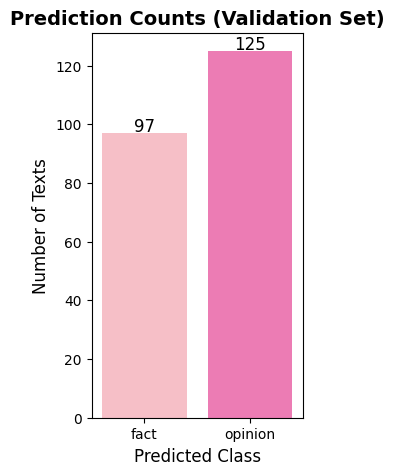

In [139]:
plt.figure(figsize=(6, 5))

plt.subplot(1, 2, 1)
ax = sns.countplot(data=df_val, x='Classification', palette=['#ffb6c1', '#ff69b4'], order=['fact', 'opinion'])
plt.title('Prediction Counts (Validation Set)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('Number of Texts', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')